# EOS-fit reweight diagnostics notebook

This notebook is a **clean, EOS-fit-only** plotting notebook for one event.

It does three things:

1. loads the **before-reweight** and **after-reweight** EOS-fit posteriors,
2. loads the saved `*_reweight_arrays.npz` cache and plots a few **diagnostics**,
3. makes an **overlaid corner plot** comparing **before vs after reweight**.

The plotting style stays close to the previous notebook by using **bilby's own** `plot_multiple` corner plotting utility, while the diagnostics use direct `matplotlib` plots.

In [18]:
# ==============================
# Configuration
# ==============================
POP_OUTDIR   = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_SEOBNR"
EOSFIT_OUTDIR = "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR"

EVENT_INDEX = 8
EVENT_NAME = f"event_{EVENT_INDEX:04d}"

EOSFIT_LABEL    = f"bns_{EVENT_NAME}_seobnr"
EOSFIT_RW_LABEL = EOSFIT_LABEL + "_reweighted"

# Optional explicit override; leave as None to use the default naming convention.
RW_CACHE_FILE = None

# Parameters shown in the overlay corner plot
CORNER_PARAMS = [
    "mass_ratio",
    "chirp_mass",
    "luminosity_distance",
    "lambda_tilde",
    "delta_lambda_tilde",
    "H0_sample",
    "delta_a0",
    "delta_a1",
    "delta_a2",
]

# Parameters used in simple 1D weighted/unweighted comparisons
DIAG_1D_PARAMS = [
    "lambda_tilde",
    "delta_lambda_tilde",
    "luminosity_distance",
    "mass_ratio",
]

# Scatter diagnostic: x-axis parameter
DELTA_LL_X = "lambda_tilde"

# Optional duplicate cap on the reweighted posterior *for plotting only*.
CAP_REWEIGHTED_DUPLICATES = False
MAX_DUP_PER_POINT = 3
ROUND_DECIMALS = 9

In [19]:
import os
import json
import copy
import warnings

import bilby
import corner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM, Planck18

warnings.filterwarnings("ignore", category=RuntimeWarning)


# =========================================================
# Generic helpers
# =========================================================
def ensure_dataframe(x):
    if isinstance(x, pd.DataFrame):
        return x.copy()
    if isinstance(x, dict):
        return pd.DataFrame(x)
    return pd.DataFrame(x)


def rename_legacy_mass_columns(df):
    df = ensure_dataframe(df)
    rename_map = {}
    if "mass_1_detector" in df.columns and "mass_1" not in df.columns:
        rename_map["mass_1_detector"] = "mass_1"
    if "mass_2_detector" in df.columns and "mass_2" not in df.columns:
        rename_map["mass_2_detector"] = "mass_2"
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def load_meta(pop_outdir, event_name):
    meta_path = os.path.join(pop_outdir, event_name, "meta.json")
    with open(meta_path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_base_result(outdir, label):
    candidates = [
        os.path.join(outdir, f"{label}_result.hdf5"),
        os.path.join(outdir, f"{label}_result.h5"),
        os.path.join(outdir, f"{label}_result.json"),
        os.path.join(outdir, f"{label}_result.pkl"),
    ]
    existing = [p for p in candidates if os.path.exists(p)]
    if not existing:
        raise FileNotFoundError("Cannot find result file. Tried:\n  " + "\n  ".join(candidates))

    last_err = None
    for result_path in existing:
        try:
            result = bilby.core.result.read_in_result(filename=result_path)
            return result, result_path
        except Exception as e:
            last_err = e
    raise RuntimeError(
        "Found result files but none could be read by bilby. Tried:\n  "
        + "\n  ".join(existing)
        + f"\nLast error: {last_err}"
    )


def load_eosfit_dataset(outdir, label, rw_label=None, use_reweighted=False):
    base_result, base_result_path = load_base_result(outdir, label)

    if use_reweighted:
        active_label = rw_label or (label + "_reweighted")
    else:
        active_label = label

    csv_path = os.path.join(outdir, f"{active_label}_posterior_augmented.csv")
    if os.path.exists(csv_path):
        posterior_df = pd.read_csv(csv_path)
        src = csv_path
    else:
        result_path = os.path.join(outdir, f"{active_label}_result.hdf5")
        if os.path.exists(result_path):
            res = bilby.core.result.read_in_result(filename=result_path)
            posterior_df = ensure_dataframe(res.posterior)
            src = result_path
        elif use_reweighted:
            raise FileNotFoundError(
                f"Could not find reweighted posterior for {active_label}. "
                f"Tried {csv_path} and {result_path}"
            )
        else:
            posterior_df = ensure_dataframe(base_result.posterior)
            src = base_result_path

    posterior_df = rename_legacy_mass_columns(posterior_df)
    return {
        "base_result": base_result,
        "base_result_path": base_result_path,
        "posterior_df_raw": posterior_df,
        "posterior_source": src,
        "active_label": active_label,
    }


# =========================================================
# EOS-fit helpers aligned with the PE script
# =========================================================
H0_TRUE = float(Planck18.H0.value)
LAMBDA_FIT_NORM = 3500.0
A0_FIT = -0.30781804
A1_FIT = 0.79244108
A2_FIT = -0.51480556
DELTA_TRUE = 0.0

cosmo_fid = FlatLambdaCDM(H0=70.0, Om0=float(Planck18.Om0), Tcmb0=Planck18.Tcmb0)
_z_grid = np.linspace(0.0, 2.0, 20000)
_dL_grid = np.asarray(cosmo_fid.luminosity_distance(_z_grid).value, dtype=float)


def z_from_dL_H0_vec(dL_mpc, H0):
    dL_scaled = np.asarray(dL_mpc, dtype=float) * (np.asarray(H0, dtype=float) / 70.0)
    return np.interp(np.clip(dL_scaled, _dL_grid[0], _dL_grid[-1]), _dL_grid, _z_grid)


def lambda_of_mbar_vec(mbar, delta_a0, delta_a1, delta_a2):
    mbar = np.asarray(mbar, dtype=float)
    poly = (
        1.0
        + A0_FIT * (1.0 + np.asarray(delta_a0, dtype=float))
        + A1_FIT * (1.0 + np.asarray(delta_a1, dtype=float)) * mbar
        + A2_FIT * (1.0 + np.asarray(delta_a2, dtype=float)) * mbar**2
    )
    lam = LAMBDA_FIT_NORM * poly / mbar**5
    lam = np.where(np.isfinite(lam), lam, 0.0)
    return np.maximum(lam, 1e-8)


def add_eosfit_derived_columns(df, h0_default=H0_TRUE):
    df = ensure_dataframe(df)
    df = rename_legacy_mass_columns(df)
    p = df.copy()

    need = {"luminosity_distance", "chirp_mass", "mass_ratio"}
    missing = need.difference(p.columns)
    if missing:
        raise ValueError(f"EOS-fit conversion needs columns: {sorted(missing)}")

    dL = p["luminosity_distance"].to_numpy(dtype=float)
    H0 = p["H0_sample"].to_numpy(dtype=float) if "H0_sample" in p.columns else np.full(len(p), h0_default)
    q = p["mass_ratio"].to_numpy(dtype=float)
    Mc = p["chirp_mass"].to_numpy(dtype=float)

    m1, m2 = bilby.gw.conversion.chirp_mass_and_mass_ratio_to_component_masses(Mc, q)
    z = z_from_dL_H0_vec(dL, H0)

    m1_src = np.asarray(m1, dtype=float) / (1.0 + z)
    m2_src = np.asarray(m2, dtype=float) / (1.0 + z)

    delta_a0 = p["delta_a0"].to_numpy(dtype=float) if "delta_a0" in p.columns else np.zeros(len(p))
    delta_a1 = p["delta_a1"].to_numpy(dtype=float) if "delta_a1" in p.columns else np.zeros(len(p))
    delta_a2 = p["delta_a2"].to_numpy(dtype=float) if "delta_a2" in p.columns else np.zeros(len(p))

    lam1 = lambda_of_mbar_vec(m1_src, delta_a0, delta_a1, delta_a2)
    lam2 = lambda_of_mbar_vec(m2_src, delta_a0, delta_a1, delta_a2)

    p["mass_1"] = m1
    p["mass_2"] = m2
    p["mass_1_source"] = m1_src
    p["mass_2_source"] = m2_src
    p["redshift_sample"] = z
    p["lambda_1"] = lam1
    p["lambda_2"] = lam2
    p["lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_lambda_tilde(lam1, lam2, m1, m2)
    p["delta_lambda_tilde"] = bilby.gw.conversion.lambda_1_lambda_2_to_delta_lambda_tilde(lam1, lam2, m1, m2)
    return p


def finite_clean(df, params):
    keep = [p for p in params if p in df.columns]
    out = df[keep].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return out


def count_duplicate_rows(df, keys, round_decimals=9):
    df = ensure_dataframe(df)
    if len(df) == 0:
        return 0, 0, 0
    key_df = df[keys].copy()
    for k in keys:
        key_df[k] = pd.to_numeric(key_df[k], errors="coerce")
    key_df = key_df.replace([np.inf, -np.inf], np.nan).dropna().round(round_decimals)
    if len(key_df) == 0:
        return len(df), 0, 0
    grp = pd.util.hash_pandas_object(key_df, index=False)
    counts = grp.value_counts()
    unique_rows = int(len(counts))
    dup_extra = int((counts - 1).clip(lower=0).sum())
    max_mult = int(counts.max())
    return unique_rows, dup_extra, max_mult


def cap_duplicate_rows_for_plot(df, keys, max_per_point=3, round_decimals=9, random_state=24680):
    df = ensure_dataframe(df)
    if len(df) == 0:
        return df.reset_index(drop=True)
    key_df = df[keys].copy()
    for k in keys:
        key_df[k] = pd.to_numeric(key_df[k], errors="coerce")
    key_df = key_df.replace([np.inf, -np.inf], np.nan)
    valid_mask = key_df.notna().all(axis=1)
    df_valid = df.loc[valid_mask].copy()
    key_valid = key_df.loc[valid_mask].round(round_decimals)
    if len(df_valid) == 0:
        return df.iloc[0:0].copy()
    group_id = pd.util.hash_pandas_object(key_valid, index=False).to_numpy()
    df_valid["__dup_group__"] = group_id
    parts = []
    rng = np.random.default_rng(random_state)
    for _, g in df_valid.groupby("__dup_group__", sort=False):
        if len(g) <= max_per_point:
            parts.append(g)
        else:
            rs = int(rng.integers(0, 2**31 - 1))
            parts.append(g.sample(n=max_per_point, random_state=rs, replace=False))
    out = pd.concat(parts, ignore_index=True)
    out = out.drop(columns=["__dup_group__"], errors="ignore").reset_index(drop=True)
    return out


# =========================================================
# Truths / labels / light-weight Result objects
# =========================================================
LABEL_MAP = {
    "chirp_mass": r"$\mathcal{M}_c$",
    "mass_ratio": r"$q$",
    "luminosity_distance": r"$d_L$",
    "redshift_sample": r"$z$",
    "H0_sample": r"$H_0$",
    "delta_a0": r"$\delta a_0$",
    "delta_a1": r"$\delta a_1$",
    "delta_a2": r"$\delta a_2$",
    "lambda_tilde": r"$\tilde{\Lambda}$",
    "delta_lambda_tilde": r"$\delta\tilde{\Lambda}$",
    "lambda_1": r"$\Lambda_1$",
    "lambda_2": r"$\Lambda_2$",
    "mass_1": r"$m_1^{\rm det}$",
    "mass_2": r"$m_2^{\rm det}$",
}


def build_priors_for_plot(base_result, df, params):
    priors_for_plot = {}
    for p in params:
        if p in base_result.priors:
            priors_for_plot[p] = base_result.priors[p]
        else:
            x = pd.to_numeric(df[p], errors="coerce").to_numpy(dtype=float)
            x = x[np.isfinite(x)]
            peak = float(np.nanmedian(x)) if x.size else 0.0
            priors_for_plot[p] = bilby.core.prior.DeltaFunction(peak=peak, name=p)
    return priors_for_plot


def make_lightweight_result(base_result, df, params, result_label):
    labels = [LABEL_MAP.get(p, p) for p in params]
    priors_for_plot = build_priors_for_plot(base_result, df, params)
    res = bilby.core.result.Result(
        label=result_label,
        outdir=base_result.outdir,
        sampler=base_result.sampler,
        search_parameter_keys=params,
        priors=priors_for_plot,
        posterior=df[params].copy(),
        parameter_labels=labels,
        parameter_labels_with_unit=labels,
    )
    res.injection_parameters = None
    return res


def add_truth_lines(fig, plot_params, truths):
    if truths is None:
        return fig
    ndim = len(plot_params)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i, yparam in enumerate(plot_params):
        ytruth = truths.get(yparam, None)
        if ytruth is not None and np.isfinite(ytruth):
            axes[i, i].axvline(ytruth, color="red", lw=1.5)
        for j in range(i):
            xparam = plot_params[j]
            xtruth = truths.get(xparam, None)
            ax = axes[i, j]
            if xtruth is not None and np.isfinite(xtruth):
                ax.axvline(xtruth, color="red", lw=1.0)
            if ytruth is not None and np.isfinite(ytruth):
                ax.axhline(ytruth, color="red", lw=1.0)
    return fig


def plot_bilby_multiple(result_list, labels, plot_params, truths=None, bins=40, plot_datapoints=False, smooth=None, smooth1d=None, **kwargs):
    plot_kwargs = dict(
        labels=labels,
        parameters=plot_params,
        save=False,
        bins=bins,
        plot_datapoints=plot_datapoints,
        **kwargs,
    )
    if smooth is not None:
        plot_kwargs["smooth"] = smooth
    if smooth1d is not None:
        plot_kwargs["smooth1d"] = smooth1d

    fig = bilby.core.result.plot_multiple(result_list, **plot_kwargs)
    add_truth_lines(fig, plot_params, truths)
    plt.show()
    return fig


# =========================================================
# Reweight cache helpers
# =========================================================
def default_cache_path(outdir, rw_label):
    return os.path.join(outdir, f"{rw_label}_reweight_arrays.npz")


def load_reweight_cache(cache_path):
    data = np.load(cache_path, allow_pickle=True)
    posterior = pd.DataFrame(data["posterior_dict"][0])
    lnw = np.asarray(data["ln_weights"], dtype=float)
    new_ll = np.asarray(data["new_log_likelihood"], dtype=float)
    new_lp = np.asarray(data["new_log_prior"], dtype=float)
    old_ll = np.asarray(data["old_log_likelihood"], dtype=float)
    old_lp = np.asarray(data["old_log_prior"], dtype=float)
    metadata = dict(data["metadata"][0])
    return posterior, lnw, new_ll, new_lp, old_ll, old_lp, metadata


def normalized_weights_from_lnw(lnw):
    lnw = np.asarray(lnw, dtype=float)
    finite = np.isfinite(lnw)
    if not finite.any():
        raise ValueError("No finite log-weights.")
    lnw_f = lnw[finite]
    w_rel = np.exp(lnw_f - np.max(lnw_f))
    w = np.zeros_like(lnw, dtype=float)
    w[finite] = w_rel / np.sum(w_rel)
    return w


def weighted_quantile(values, weights, qs):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[mask]
    weights = weights[mask]
    if len(values) == 0:
        return np.full(len(np.atleast_1d(qs)), np.nan)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]
    return np.interp(np.atleast_1d(qs), cdf, values)

In [20]:
# =========================================================
# Load metadata, before/after posteriors, and cache
# =========================================================
meta = load_meta(POP_OUTDIR, EVENT_NAME)
inj = dict(meta["injection_parameters"])
m1_det = float(meta["mass_1_detector"])
m2_det = float(meta["mass_2_detector"])

truths = {
    "chirp_mass": (m1_det * m2_det) ** (3.0 / 5.0) / (m1_det + m2_det) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det, m2_det) / max(m1_det, m2_det),
    "luminosity_distance": float(inj["luminosity_distance"]),
    "mass_1": m1_det,
    "mass_2": m2_det,
}

before_loaded = load_eosfit_dataset(
    EOSFIT_OUTDIR,
    EOSFIT_LABEL,
    rw_label=EOSFIT_RW_LABEL,
    use_reweighted=False,
)
after_loaded = load_eosfit_dataset(
    EOSFIT_OUTDIR,
    EOSFIT_LABEL,
    rw_label=EOSFIT_RW_LABEL,
    use_reweighted=True,
)

before_df_full = add_eosfit_derived_columns(before_loaded["posterior_df_raw"])
after_df_full = add_eosfit_derived_columns(after_loaded["posterior_df_raw"])

if CAP_REWEIGHTED_DUPLICATES:
    before_unique, before_dup, before_maxmult = count_duplicate_rows(before_df_full, CORNER_PARAMS, round_decimals=ROUND_DECIMALS)
    after_unique, after_dup, after_maxmult = count_duplicate_rows(after_df_full, CORNER_PARAMS, round_decimals=ROUND_DECIMALS)
    print(f"[before] n={len(before_df_full)}, unique={before_unique}, dup_extra={before_dup}, max_mult={before_maxmult}")
    print(f"[after ] n={len(after_df_full)}, unique={after_unique}, dup_extra={after_dup}, max_mult={after_maxmult}")
    after_df_full = cap_duplicate_rows_for_plot(
        after_df_full,
        keys=CORNER_PARAMS,
        max_per_point=MAX_DUP_PER_POINT,
        round_decimals=ROUND_DECIMALS,
    )
    after_unique2, after_dup2, after_maxmult2 = count_duplicate_rows(after_df_full, CORNER_PARAMS, round_decimals=ROUND_DECIMALS)
    print(f"[after capped] n={len(after_df_full)}, unique={after_unique2}, dup_extra={after_dup2}, max_mult={after_maxmult2}")

CACHE_PATH = RW_CACHE_FILE or default_cache_path(EOSFIT_OUTDIR, EOSFIT_RW_LABEL)
posterior_cache_df, lnw, new_ll, new_lp, old_ll, old_lp, cache_meta = load_reweight_cache(CACHE_PATH)
cache_weights = normalized_weights_from_lnw(lnw)

print("Before posterior source :", before_loaded["posterior_source"])
print("After posterior source  :", after_loaded["posterior_source"])
print("Reweight cache          :", CACHE_PATH)
print("Cache metadata keys     :", sorted(cache_meta.keys()))
print("n(before), n(after), n(cache) =", len(before_df_full), len(after_df_full), len(posterior_cache_df))

09:59 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
09:59 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


Before posterior source : /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/bns_event_0008_seobnr_posterior_augmented.csv
After posterior source  : /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/bns_event_0008_seobnr_reweighted_posterior_augmented.csv
Reweight cache          : /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/bns_event_0008_seobnr_reweighted_reweight_arrays.npz
Cache metadata keys     : ['distance_marginalization', 'event_index', 'event_name', 'label', 'lal_data_path', 'new_waveform_source_model', 'old_waveform_source_model', 'phase_marginalization', 'pop_outdir', 'reference_frame', 'rw_label', 'signal_path', 'sky_frame', 'time_marginalization', 'use_nested_samples', 'waveform_approximant']
n(before), n(after), n(cache) = 6109 5950 6109


ESS           = 5950.366
ESS fraction  = 0.9740
max weight    = 0.001122
prior shift   = unique(new_lp - old_lp) -> [0.]


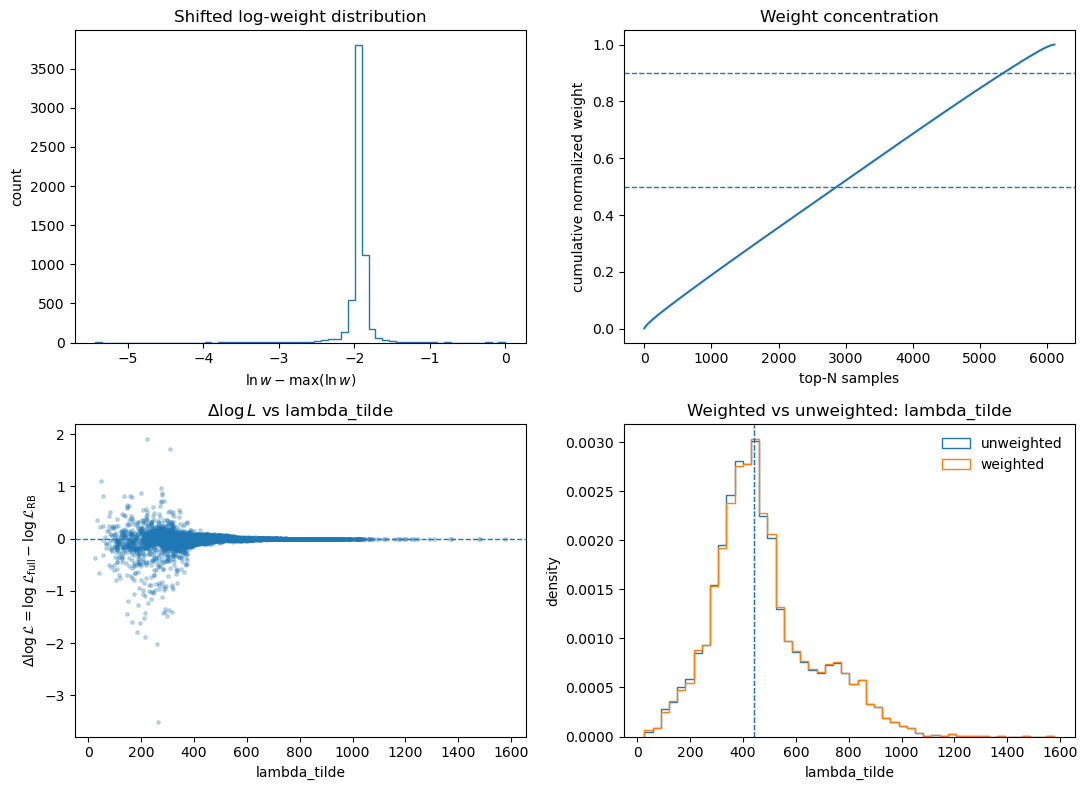

,param,unweighted_q50,weighted_q50,shift_q50,unweighted_q16,unweighted_q84,weighted_q16,weighted_q84
0,lambda_tilde,439.569191,441.643108,2.073917,305.096816,680.776714,305.859606,683.931779
1,delta_lambda_tilde,39.973738,39.909540,-0.064198,13.321409,77.642495,13.051917,77.550213
2,luminosity_distance,1306.232989,1306.822933,0.589945,1108.732990,1529.728753,1109.294154,1528.452010
3,mass_ratio,0.910692,0.911027,0.000335,0.844965,0.967838,0.845179,0.968165


In [21]:
# =========================================================
# Reweight diagnostics
# =========================================================
posterior_cache_df = add_eosfit_derived_columns(posterior_cache_df)

delta_ll = np.asarray(new_ll) - np.asarray(old_ll)
weights = cache_weights
finite = np.isfinite(lnw)
lnw_shift = np.asarray(lnw)[finite] - np.nanmax(np.asarray(lnw)[finite])

ess = 1.0 / np.sum(weights[weights > 0] ** 2)
ess_fraction = ess / np.sum(np.isfinite(weights))
max_weight = np.max(weights)

print(f"ESS           = {ess:.3f}")
print(f"ESS fraction  = {ess_fraction:.4f}")
print(f"max weight    = {max_weight:.6f}")
print(f"prior shift   = unique(new_lp - old_lp) -> {np.unique(np.round(new_lp - old_lp, 12))[:10]}")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# 1) shifted log-weights
axes[0, 0].hist(lnw_shift, bins=60, histtype="step")
axes[0, 0].set_xlabel(r"$\ln w - \max(\ln w)$")
axes[0, 0].set_ylabel("count")
axes[0, 0].set_title("Shifted log-weight distribution")

# 2) cumulative normalized weights
w_sorted = np.sort(weights[weights > 0])[::-1]
cumw = np.cumsum(w_sorted)
axes[0, 1].plot(np.arange(1, len(w_sorted) + 1), cumw)
axes[0, 1].axhline(0.5, ls="--", lw=1)
axes[0, 1].axhline(0.9, ls="--", lw=1)
axes[0, 1].set_xlabel("top-N samples")
axes[0, 1].set_ylabel("cumulative normalized weight")
axes[0, 1].set_title("Weight concentration")

# 3) delta logL vs chosen x parameter
if DELTA_LL_X not in posterior_cache_df.columns:
    raise KeyError(f"{DELTA_LL_X} not found in cached posterior columns")
x = pd.to_numeric(posterior_cache_df[DELTA_LL_X], errors="coerce").to_numpy(dtype=float)
mask = np.isfinite(x) & np.isfinite(delta_ll)
axes[1, 0].scatter(x[mask], delta_ll[mask], s=6, alpha=0.25)
axes[1, 0].axhline(0.0, ls="--", lw=1)
axes[1, 0].set_xlabel(DELTA_LL_X)
axes[1, 0].set_ylabel(r"$\Delta \log\mathcal{L} = \log\mathcal{L}_{\rm full} - \log\mathcal{L}_{\rm RB}$")
axes[1, 0].set_title(f"$\Delta \log L$ vs {DELTA_LL_X}")

# 4) weighted vs unweighted 1D example
p = DIAG_1D_PARAMS[0]
arr = pd.to_numeric(posterior_cache_df[p], errors="coerce").to_numpy(dtype=float)
mask = np.isfinite(arr) & np.isfinite(weights)
axes[1, 1].hist(arr[mask], bins=50, histtype="step", density=True, label="unweighted")
axes[1, 1].hist(arr[mask], bins=50, histtype="step", density=True, weights=weights[mask], label="weighted")
uq16, uq50, uq84 = np.quantile(arr[mask], [0.16, 0.5, 0.84])
wq16, wq50, wq84 = weighted_quantile(arr[mask], weights[mask], [0.16, 0.5, 0.84])
axes[1, 1].axvline(uq50, lw=1, ls="--")
axes[1, 1].axvline(wq50, lw=1, ls=":")
axes[1, 1].set_xlabel(p)
axes[1, 1].set_ylabel("density")
axes[1, 1].set_title(f"Weighted vs unweighted: {p}")
axes[1, 1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Small text summary table
rows = []
for p in DIAG_1D_PARAMS:
    if p not in posterior_cache_df.columns:
        continue
    arr = pd.to_numeric(posterior_cache_df[p], errors="coerce").to_numpy(dtype=float)
    mask = np.isfinite(arr) & np.isfinite(weights)
    uq16, uq50, uq84 = np.quantile(arr[mask], [0.16, 0.5, 0.84])
    wq16, wq50, wq84 = weighted_quantile(arr[mask], weights[mask], [0.16, 0.5, 0.84])
    rows.append({
        "param": p,
        "unweighted_q50": uq50,
        "weighted_q50": wq50,
        "shift_q50": wq50 - uq50,
        "unweighted_q16": uq16,
        "unweighted_q84": uq84,
        "weighted_q16": wq16,
        "weighted_q84": wq84,
    })
pd.DataFrame(rows)

before shape: (6109, 9)
after  shape: (5950, 9)


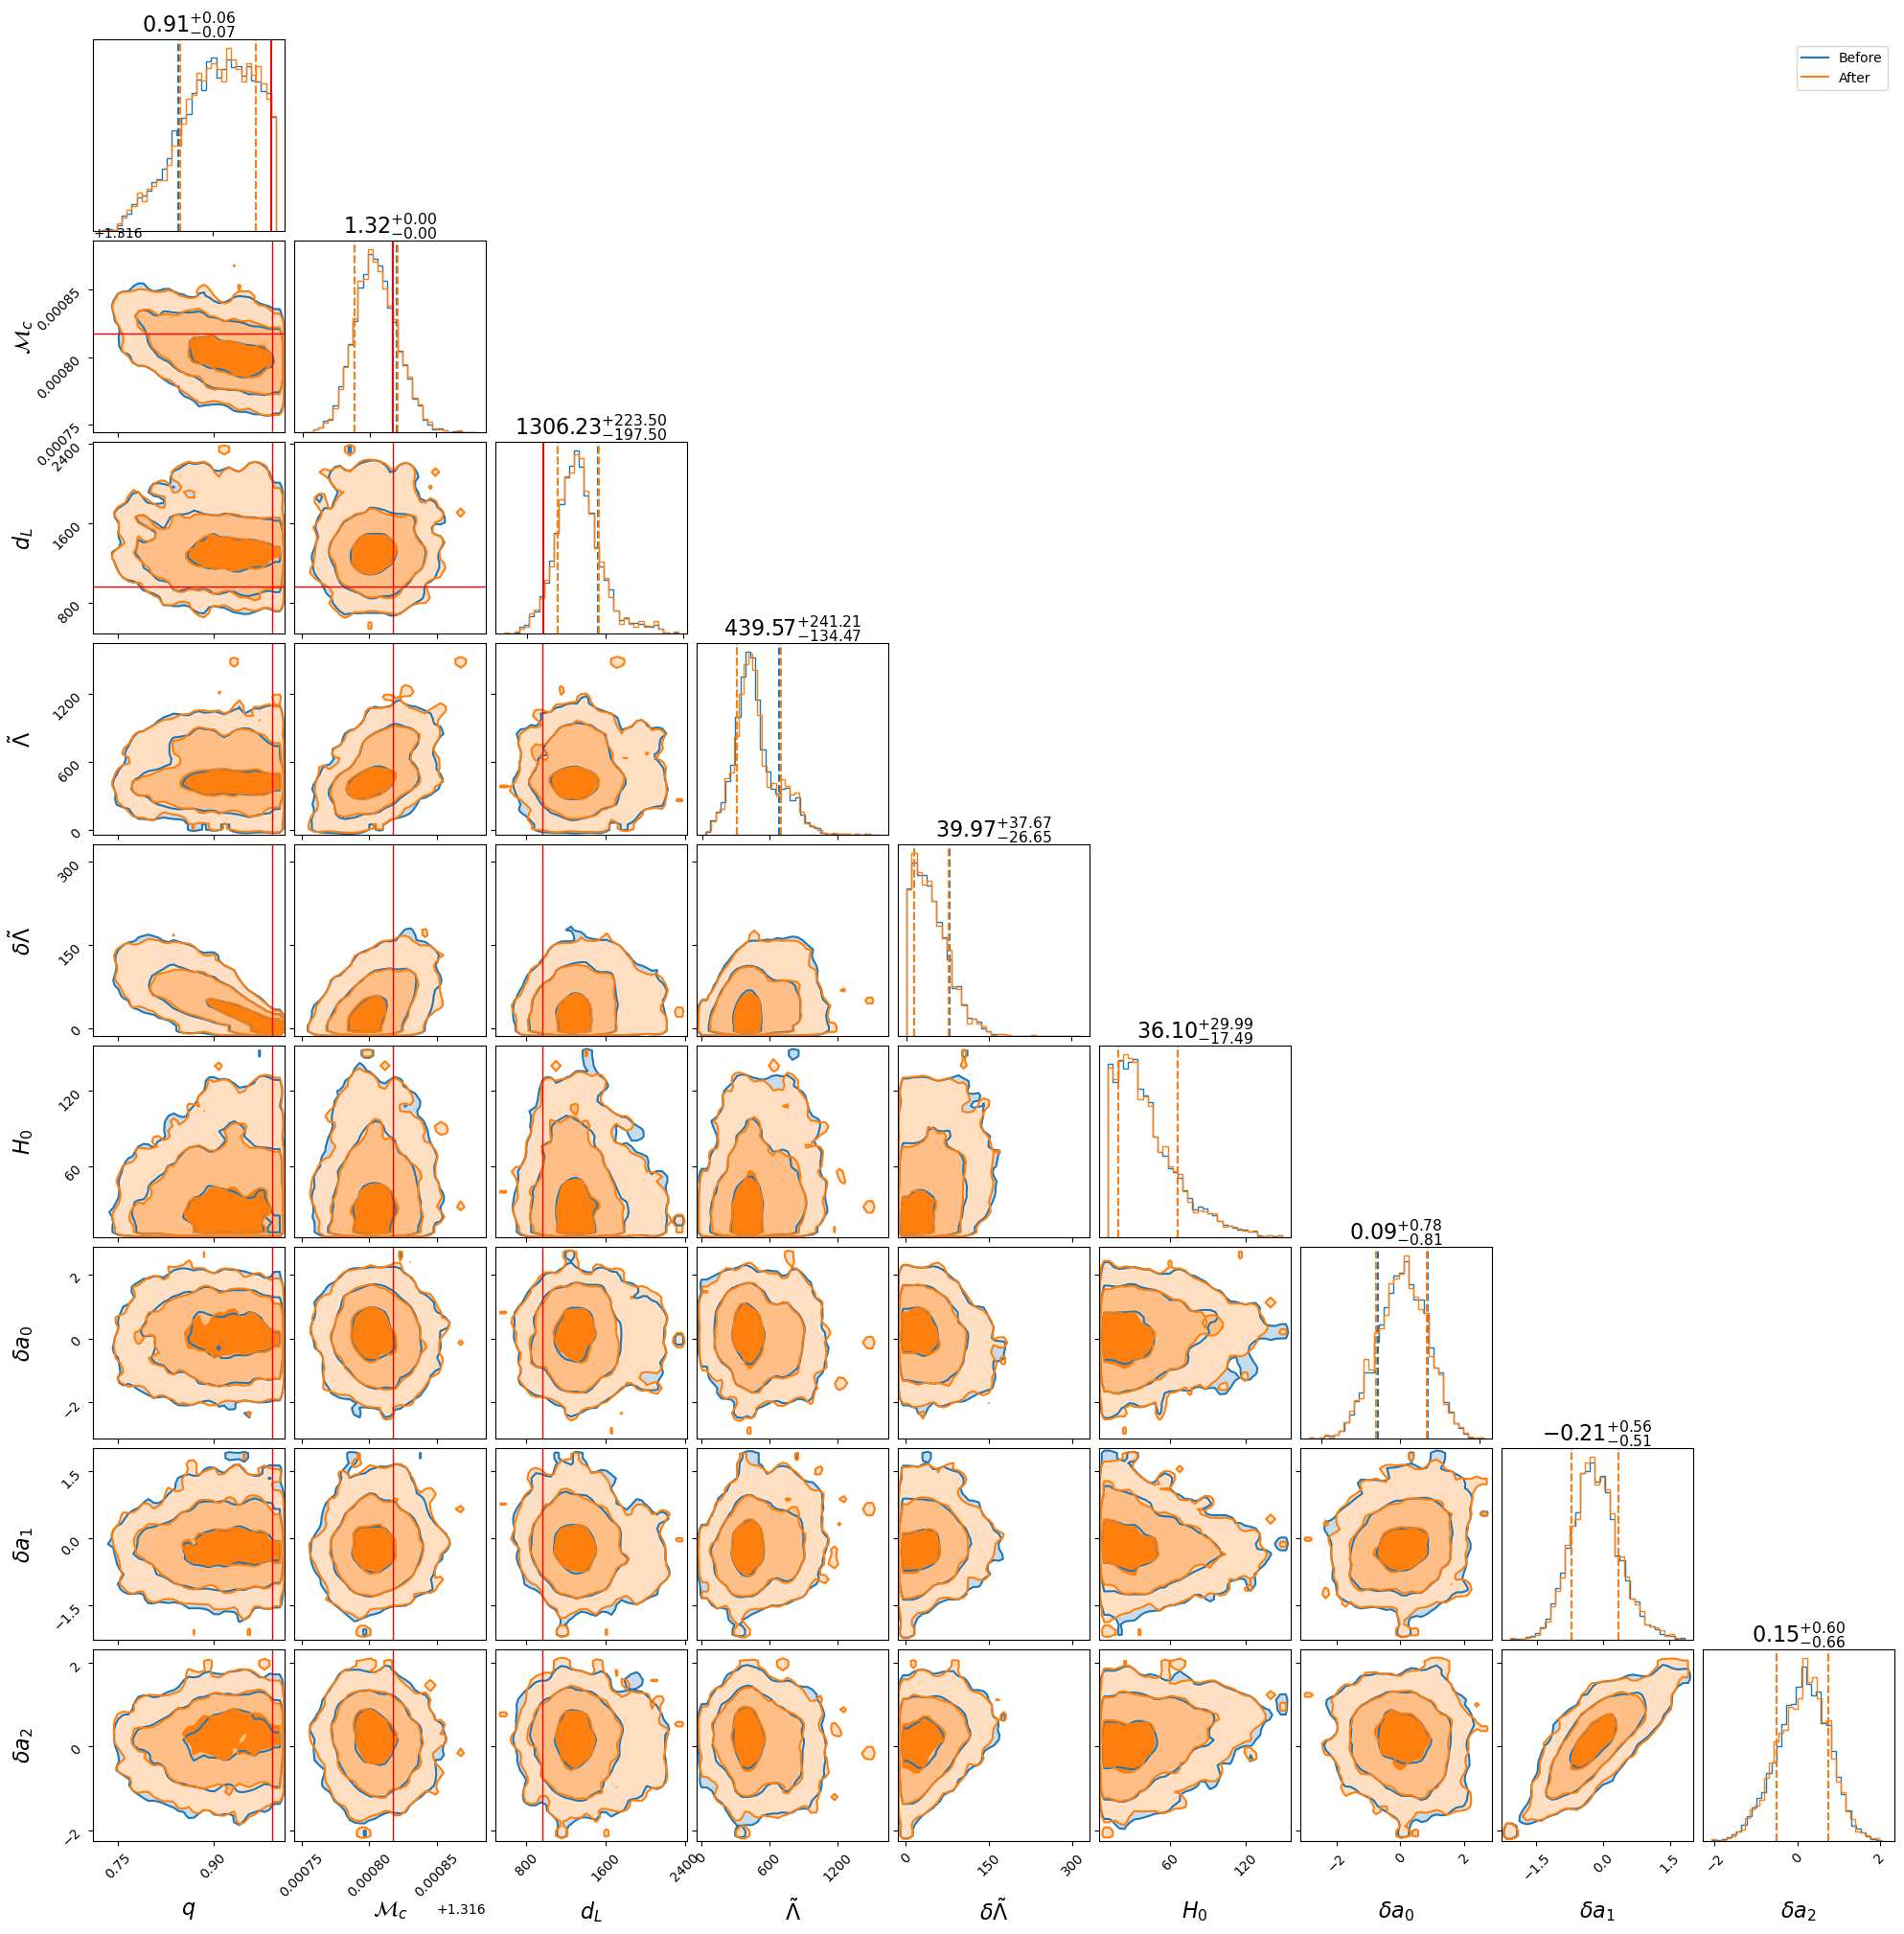

Saved overlay corner to: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/bns_event_0008_seobnr_reweighted_before_after_overlay_corner.png


In [22]:
# =========================================================
# Before vs after reweight: overlaid corner plot
# =========================================================
before_df = finite_clean(before_df_full, CORNER_PARAMS)
after_df  = finite_clean(after_df_full, CORNER_PARAMS)

print("before shape:", before_df.shape)
print("after  shape:", after_df.shape)

before_result = make_lightweight_result(
    before_loaded["base_result"],
    before_df,
    CORNER_PARAMS,
    result_label="Before reweight",
)
after_result = make_lightweight_result(
    after_loaded["base_result"],
    after_df,
    CORNER_PARAMS,
    result_label="After reweight",
)

fig = plot_bilby_multiple(
    [before_result, after_result],
    labels=["Before", "After"],
    plot_params=CORNER_PARAMS,
    truths=truths,
    bins=35,
    plot_datapoints=False,
    smooth=0.9,
    smooth1d=None,
    quantiles=[0.16, 0.84],
)

save_path = os.path.join(EOSFIT_OUTDIR, f"{EOSFIT_RW_LABEL}_before_after_overlay_corner.png")
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved overlay corner to: {save_path}")

10:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
10:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data



Loaded mband0 reweighted
  posterior source: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_mband0/bns_event_0008_eosfit_mband0_reweighted_posterior_augmented.csv
  raw samples      : 1845

Loaded SEOBNR reweighted
  posterior source: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/bns_event_0008_seobnr_reweighted_posterior_augmented.csv
  raw samples      : 5950

Corner parameters:
['mass_ratio', 'chirp_mass', 'luminosity_distance', 'lambda_tilde', 'delta_lambda_tilde', 'H0_sample', 'delta_a0', 'delta_a1', 'delta_a2']
mband0 reweighted: 1845 clean samples
SEOBNR reweighted: 5950 clean samples


10:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data
10:31 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


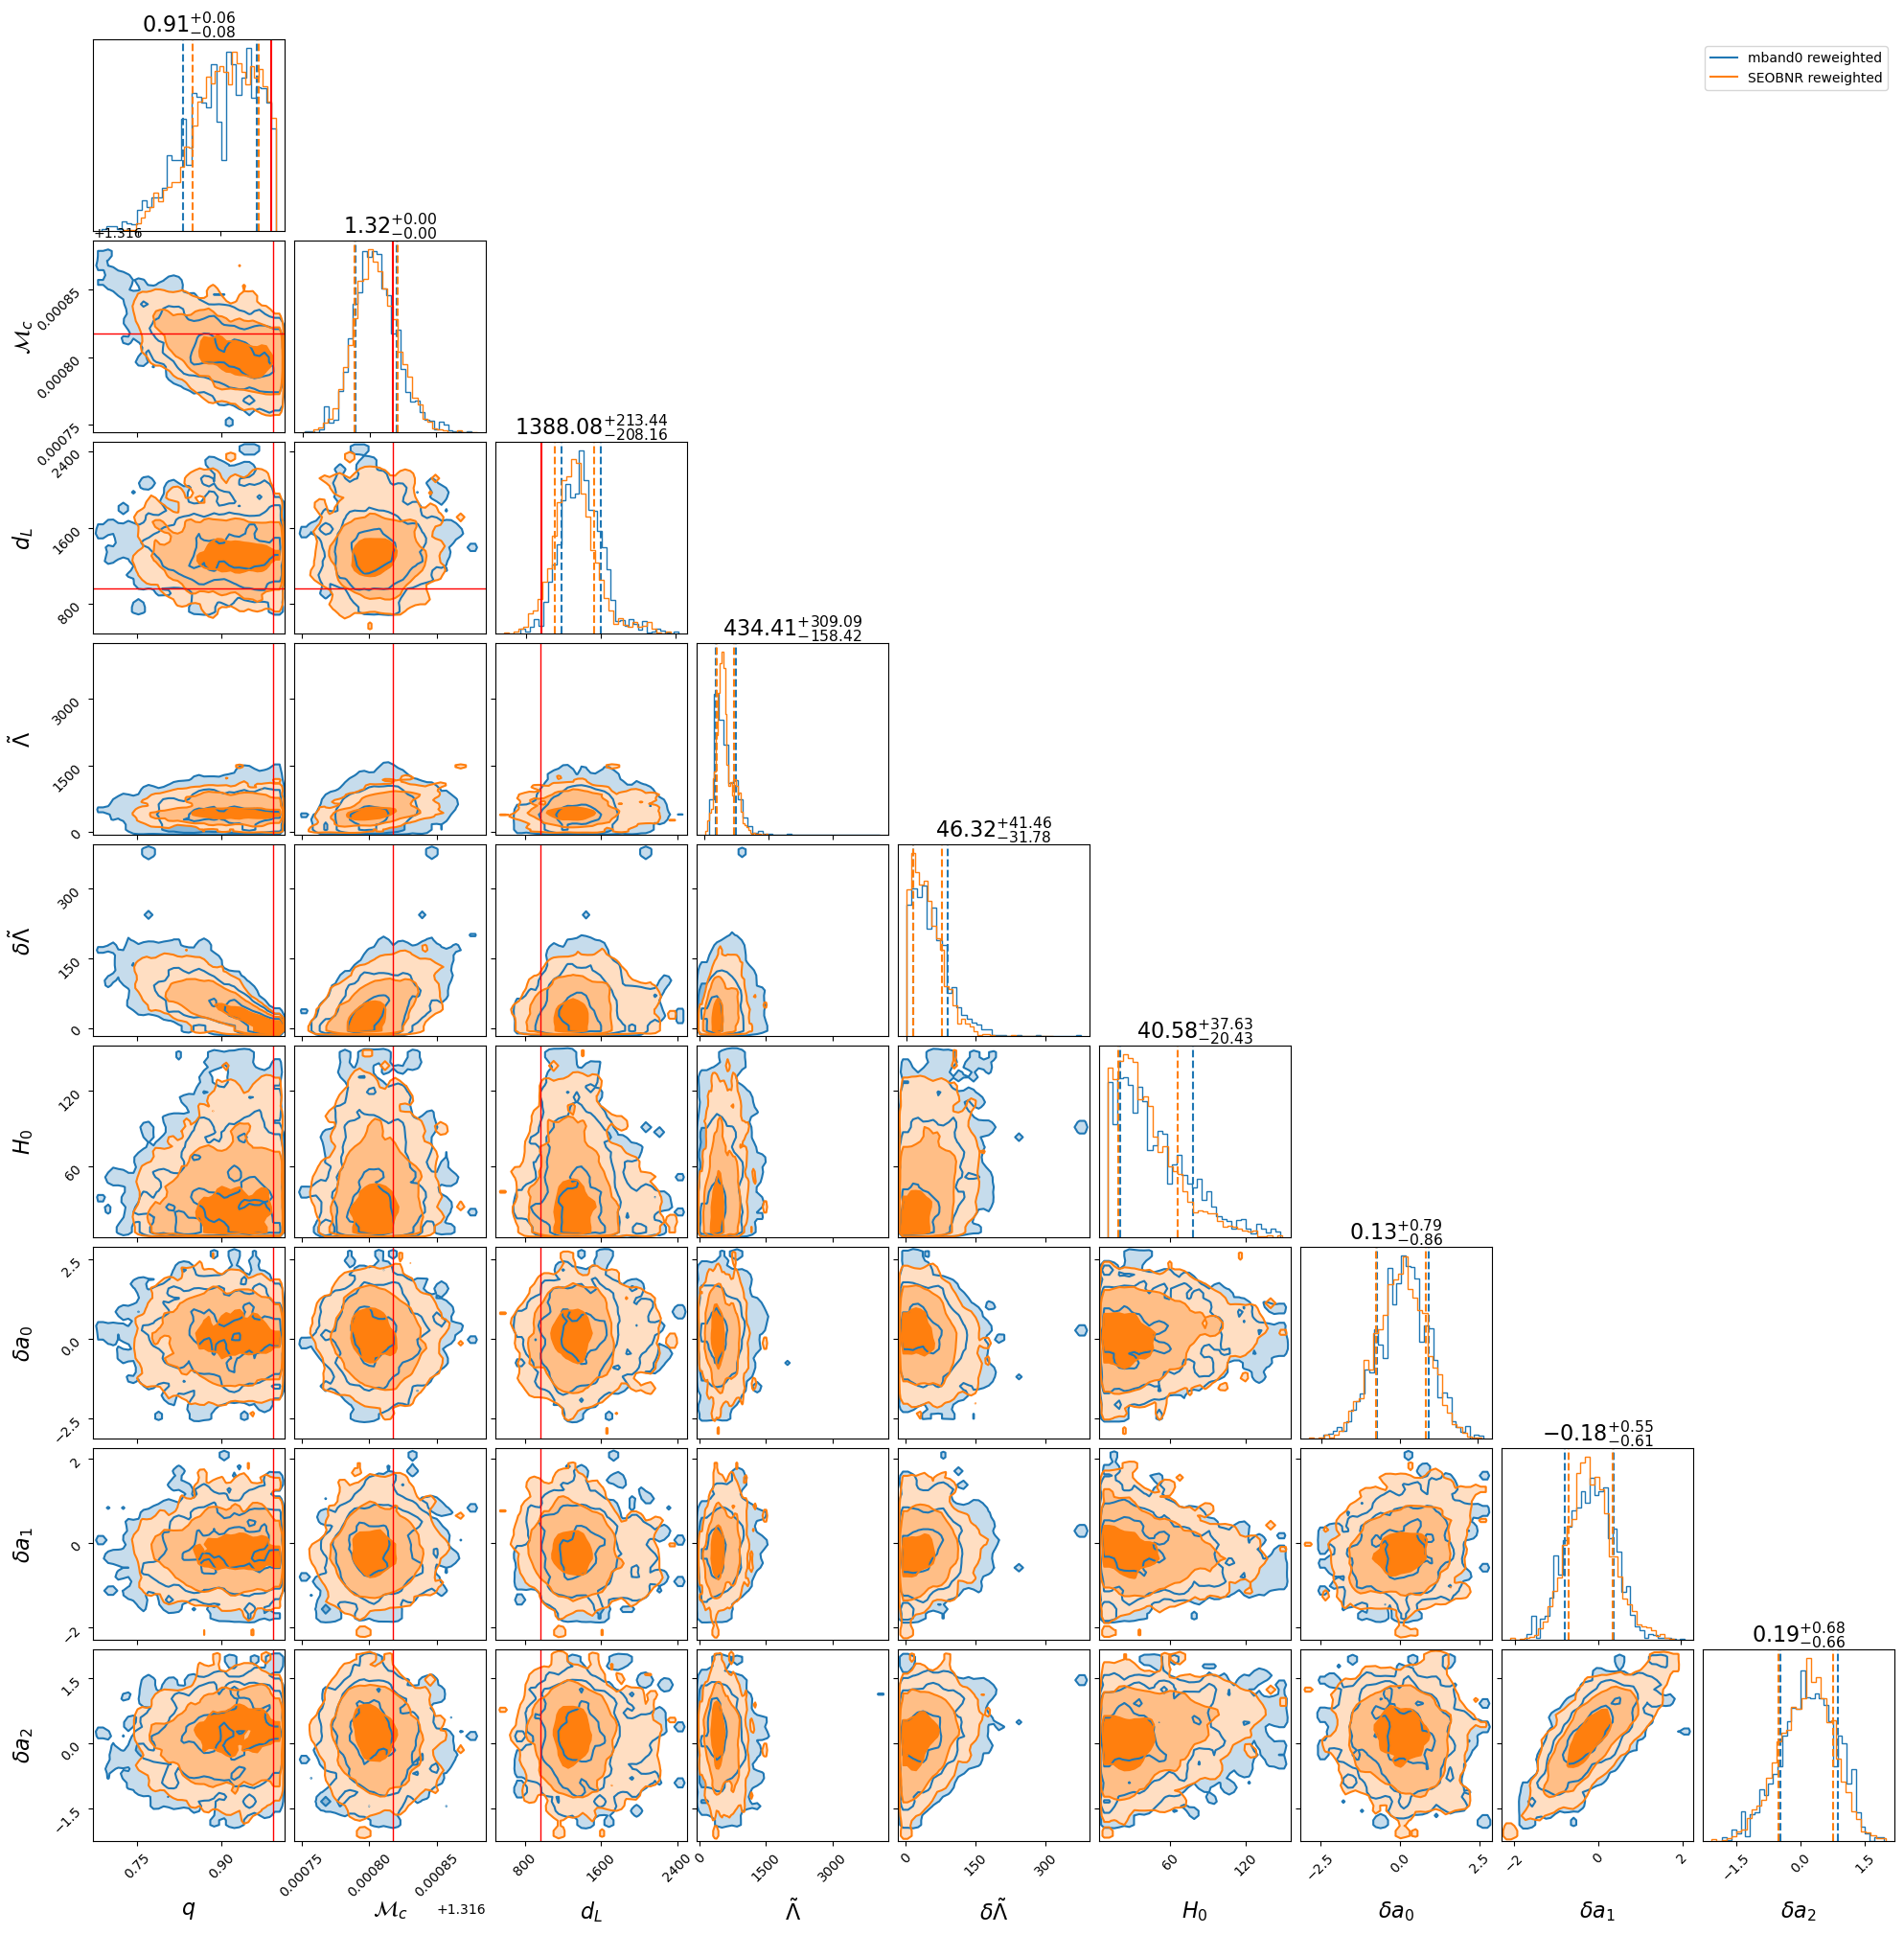


Saved: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR/event_0008_mband0_vs_SEOBNR_reweighted_overlay_corner.png


In [23]:
# =========================================================
# Compare reweighted posteriors from two waveform runs
#   1. current/eosfit mband0 run
#   2. SEOBNR run
# =========================================================

EVENT_INDEX = 8
EVENT_NAME = f"event_{EVENT_INDEX:04d}"

WAVEFORM_COMPARE_CONFIGS = [
    {
        "name": "mband0 reweighted",
        "pop_outdir": "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_exactfd_mband0",
        "eosfit_outdir": "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_mband0",
        "label": f"bns_{EVENT_NAME}_eosfit_mband0",
    },
    {
        "name": "SEOBNR reweighted",
        "pop_outdir": "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_SEOBNR",
        "eosfit_outdir": "/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_run_SEOBNR",
        "label": f"bns_{EVENT_NAME}_seobnr",
    },
]

# Use the first config for injection truth lines.
meta_cmp = load_meta(WAVEFORM_COMPARE_CONFIGS[0]["pop_outdir"], EVENT_NAME)
inj_cmp = dict(meta_cmp["injection_parameters"])
m1_det_cmp = float(meta_cmp["mass_1_detector"])
m2_det_cmp = float(meta_cmp["mass_2_detector"])

truths_cmp = {
    "chirp_mass": (m1_det_cmp * m2_det_cmp) ** (3.0 / 5.0)
    / (m1_det_cmp + m2_det_cmp) ** (1.0 / 5.0),
    "mass_ratio": min(m1_det_cmp, m2_det_cmp) / max(m1_det_cmp, m2_det_cmp),
    "luminosity_distance": float(inj_cmp["luminosity_distance"]),
    "mass_1": m1_det_cmp,
    "mass_2": m2_det_cmp,
}

compare_results = []
compare_labels = []
compare_dfs = []

for cfg in WAVEFORM_COMPARE_CONFIGS:
    rw_label = cfg["label"] + "_reweighted"

    loaded = load_eosfit_dataset(
        cfg["eosfit_outdir"],
        cfg["label"],
        rw_label=rw_label,
        use_reweighted=True,
    )

    df_full = add_eosfit_derived_columns(loaded["posterior_df_raw"])

    compare_dfs.append(df_full)
    compare_labels.append(cfg["name"])

    print(f"\nLoaded {cfg['name']}")
    print("  posterior source:", loaded["posterior_source"])
    print("  raw samples      :", len(df_full))

# Only plot parameters that exist in both reweighted posteriors.
compare_params = [
    p for p in CORNER_PARAMS
    if all(p in df.columns for df in compare_dfs)
]

if len(compare_params) < 2:
    raise RuntimeError(
        "Fewer than two common corner parameters found. "
        f"Common params: {compare_params}"
    )

print("\nCorner parameters:")
print(compare_params)

# Clean non-finite rows for corner plotting.
compare_clean_dfs = []
for label, df in zip(compare_labels, compare_dfs):
    clean = finite_clean(df, compare_params)

    if CAP_REWEIGHTED_DUPLICATES:
        clean = cap_duplicate_rows_for_plot(
            clean,
            compare_params,
            max_per_point=MAX_DUP_PER_POINT,
            round_decimals=ROUND_DECIMALS,
            random_state=24680,
        )

    compare_clean_dfs.append(clean)
    print(f"{label}: {len(clean)} clean samples")

# Build lightweight bilby Result objects.
for cfg, clean_df in zip(WAVEFORM_COMPARE_CONFIGS, compare_clean_dfs):
    loaded_base = load_eosfit_dataset(
        cfg["eosfit_outdir"],
        cfg["label"],
        rw_label=cfg["label"] + "_reweighted",
        use_reweighted=False,
    )

    res = make_lightweight_result(
        loaded_base["base_result"],
        clean_df,
        compare_params,
        result_label=cfg["name"],
    )
    compare_results.append(res)

fig = plot_bilby_multiple(
    compare_results,
    labels=compare_labels,
    plot_params=compare_params,
    truths=truths_cmp,
    bins=35,
    plot_datapoints=False,
    smooth=0.9,
    smooth1d=None,   # avoid corner/matplotlib density keyword crash
    quantiles=[0.16, 0.84],
)

save_path = os.path.join(
    WAVEFORM_COMPARE_CONFIGS[1]["eosfit_outdir"],
    f"{EVENT_NAME}_mband0_vs_SEOBNR_reweighted_overlay_corner.png",
)
fig.savefig(save_path, dpi=300, bbox_inches="tight")
print("\nSaved:", save_path)